# **Spoken Digit Recognition**

In [1]:
import os
import numpy as np
import librosa
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.utils import to_categorical

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import EarlyStopping


In [2]:
from utils.preprocess import preprocess
from utils.features import extract_mfcc

## Load dataset

In [49]:
DATASET_PATH = "dataset/"

labels = []
features = []

for digit in os.listdir(DATASET_PATH):

    digit_path = os.path.join(DATASET_PATH, digit)

    for file in os.listdir(digit_path):

        file_path = os.path.join(digit_path, file)

        # load audio
        audio, sr = librosa.load(
            file_path,
            sr=16000
        )

        labels.append(digit)
        features.append(audio)

print("Total Samples:", len(features))

Total Samples: 17000


## Preprocessing & Feature Extraction

In [38]:
X = []
y = []

for audio, label in zip(features, labels):
    audio = preprocess(audio)
    mfcc = extract_mfcc(audio)
    
    X.append(mfcc)
    y.append(label)

X = np.array(X)
X = X[..., np.newaxis]  # CNN channel

le = LabelEncoder()
y = le.fit_transform(y)
y = to_categorical(y)

## Train/Test Split

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Build Model

In [42]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input

model = Sequential()

model.add(Input(shape=X_train.shape[1:]))

model.add(Conv2D(32, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(10, activation='softmax'))

In [43]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

## Training

In [44]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/50
425/425 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.5118 - loss: 1.7710 - val_accuracy: 0.8188 - val_loss: 0.5903
Epoch 2/50
425/425 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7991 - loss: 0.6144 - val_accuracy: 0.8668 - val_loss: 0.4061
Epoch 3/50
425/425 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8707 - loss: 0.3989 - val_accuracy: 0.9091 - val_loss: 0.2892
Epoch 4/50
425/425 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8968 - loss: 0.3073 - val_accuracy: 0.9059 - val_loss: 0.2792
Epoch 5/50
425/425 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9183 - loss: 0.2411 - val_accuracy: 0.9221 - val_loss: 0.2435
Epoch 6/50
425/425 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9321 - loss: 0.2041 - val_accuracy: 0.9124 - val_loss: 0.2829
Epoch 7/50
425/425 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9379 - loss: 0.1909 - val_accuracy: 0.9244 - val_loss: 0.2502
Epoch 8/50
425/425 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9454 - loss: 0.1619 - val_accuracy: 0.

In [45]:
loss, accuracy = model.evaluate(
    X_test,
    y_test
)

print("\nTest Accuracy:", accuracy)

107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9221 - loss: 0.2435

Test Accuracy: 0.9220588207244873


In [48]:
model.save("models/spoken_digit_model.keras")

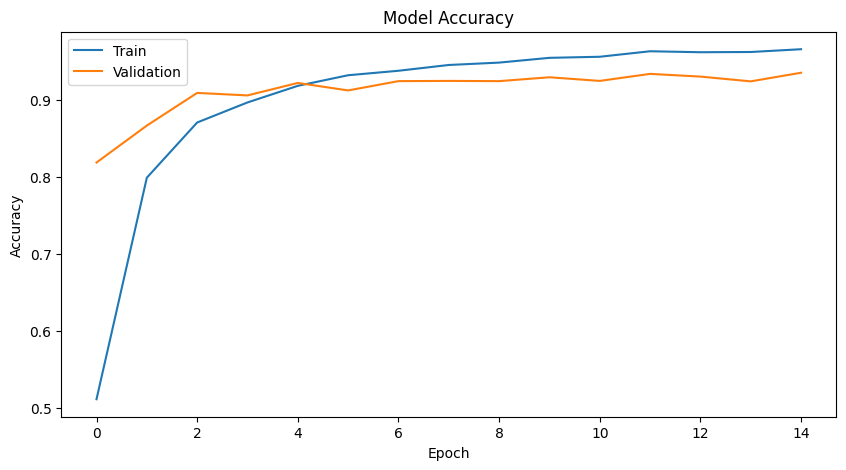

In [46]:

plt.figure(figsize=(10,5))

# accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend([
    "Train",
    "Validation"
])

plt.show()

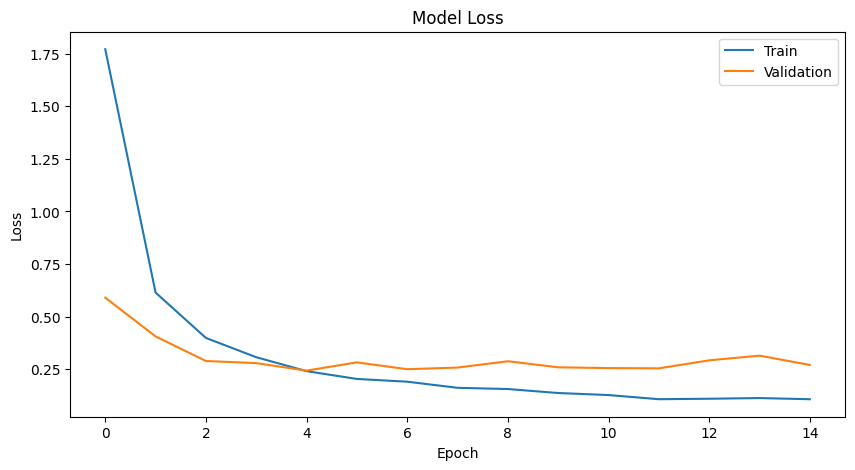

In [47]:

plt.figure(figsize=(10,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend([
    "Train",
    "Validation"
])

plt.show()